## This notebook performs a binary classification task on a
# loan dataset.
It involves data cleaning (handling missing values), exploratory data analysis (visualizing key features), and training and evaluating two classification models: Logistic Regression and Decision Tree Classifier. The goal is to predict 'Credit_History' based on other features in the dataset.

In [21]:
import pandas as pd
loan_df = pd.read_csv('/content/loan dataset.csv')

In [22]:
# Impute missing values for categorical columns with the mode
for col in ['Gender', 'Dependents', 'Self_Employed', 'Credit_History']:
    if loan_df[col].isnull().any():
        loan_df[col] = loan_df[col].fillna(loan_df[col].mode()[0])

# Impute missing values for numerical columns with the median
for col in ['LoanAmount', 'Loan_Amount_Term']:
    if loan_df[col].isnull().any():
        loan_df[col] = loan_df[col].fillna(loan_df[col].median())

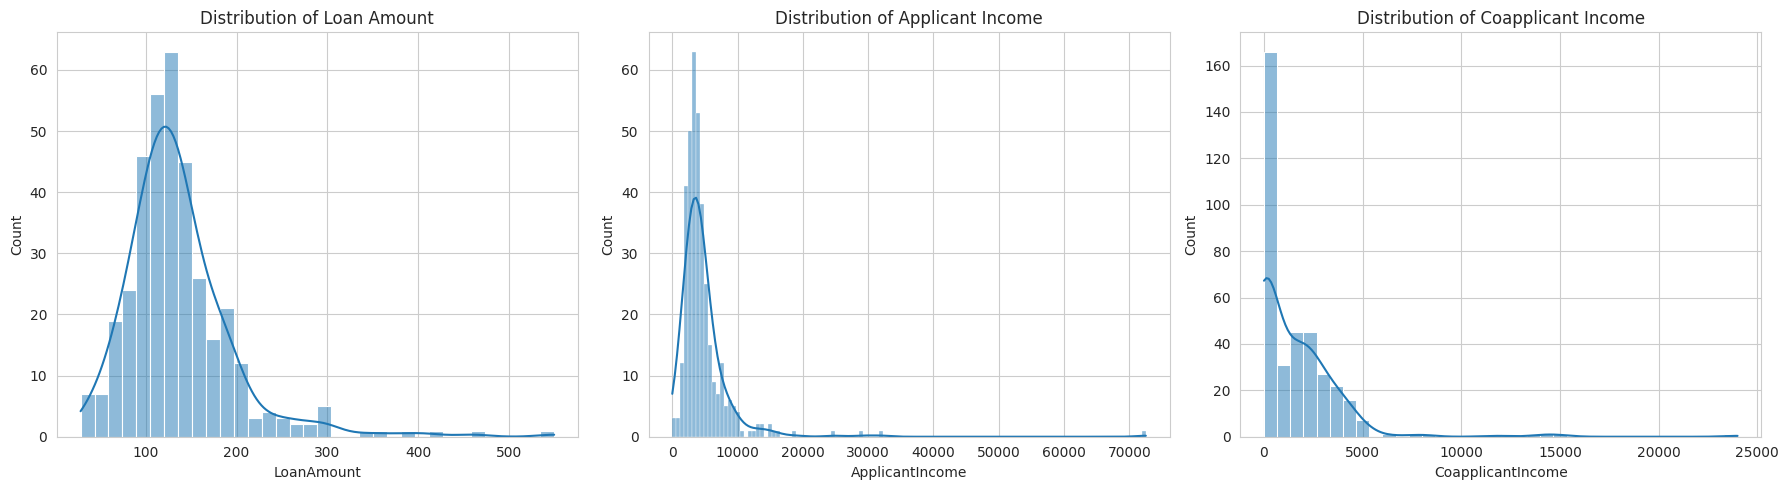

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the aesthetic style of the plots
sns.set_style("whitegrid")

# Visualize the distribution of numerical features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(loan_df['LoanAmount'], kde=True, ax=axes[0])
axes[0].set_title('Distribution of Loan Amount')

sns.histplot(loan_df['ApplicantIncome'], kde=True, ax=axes[1])
axes[1].set_title('Distribution of Applicant Income')

sns.histplot(loan_df['CoapplicantIncome'], kde=True, ax=axes[2])
axes[2].set_title('Distribution of Coapplicant Income')

plt.tight_layout()
plt.show()

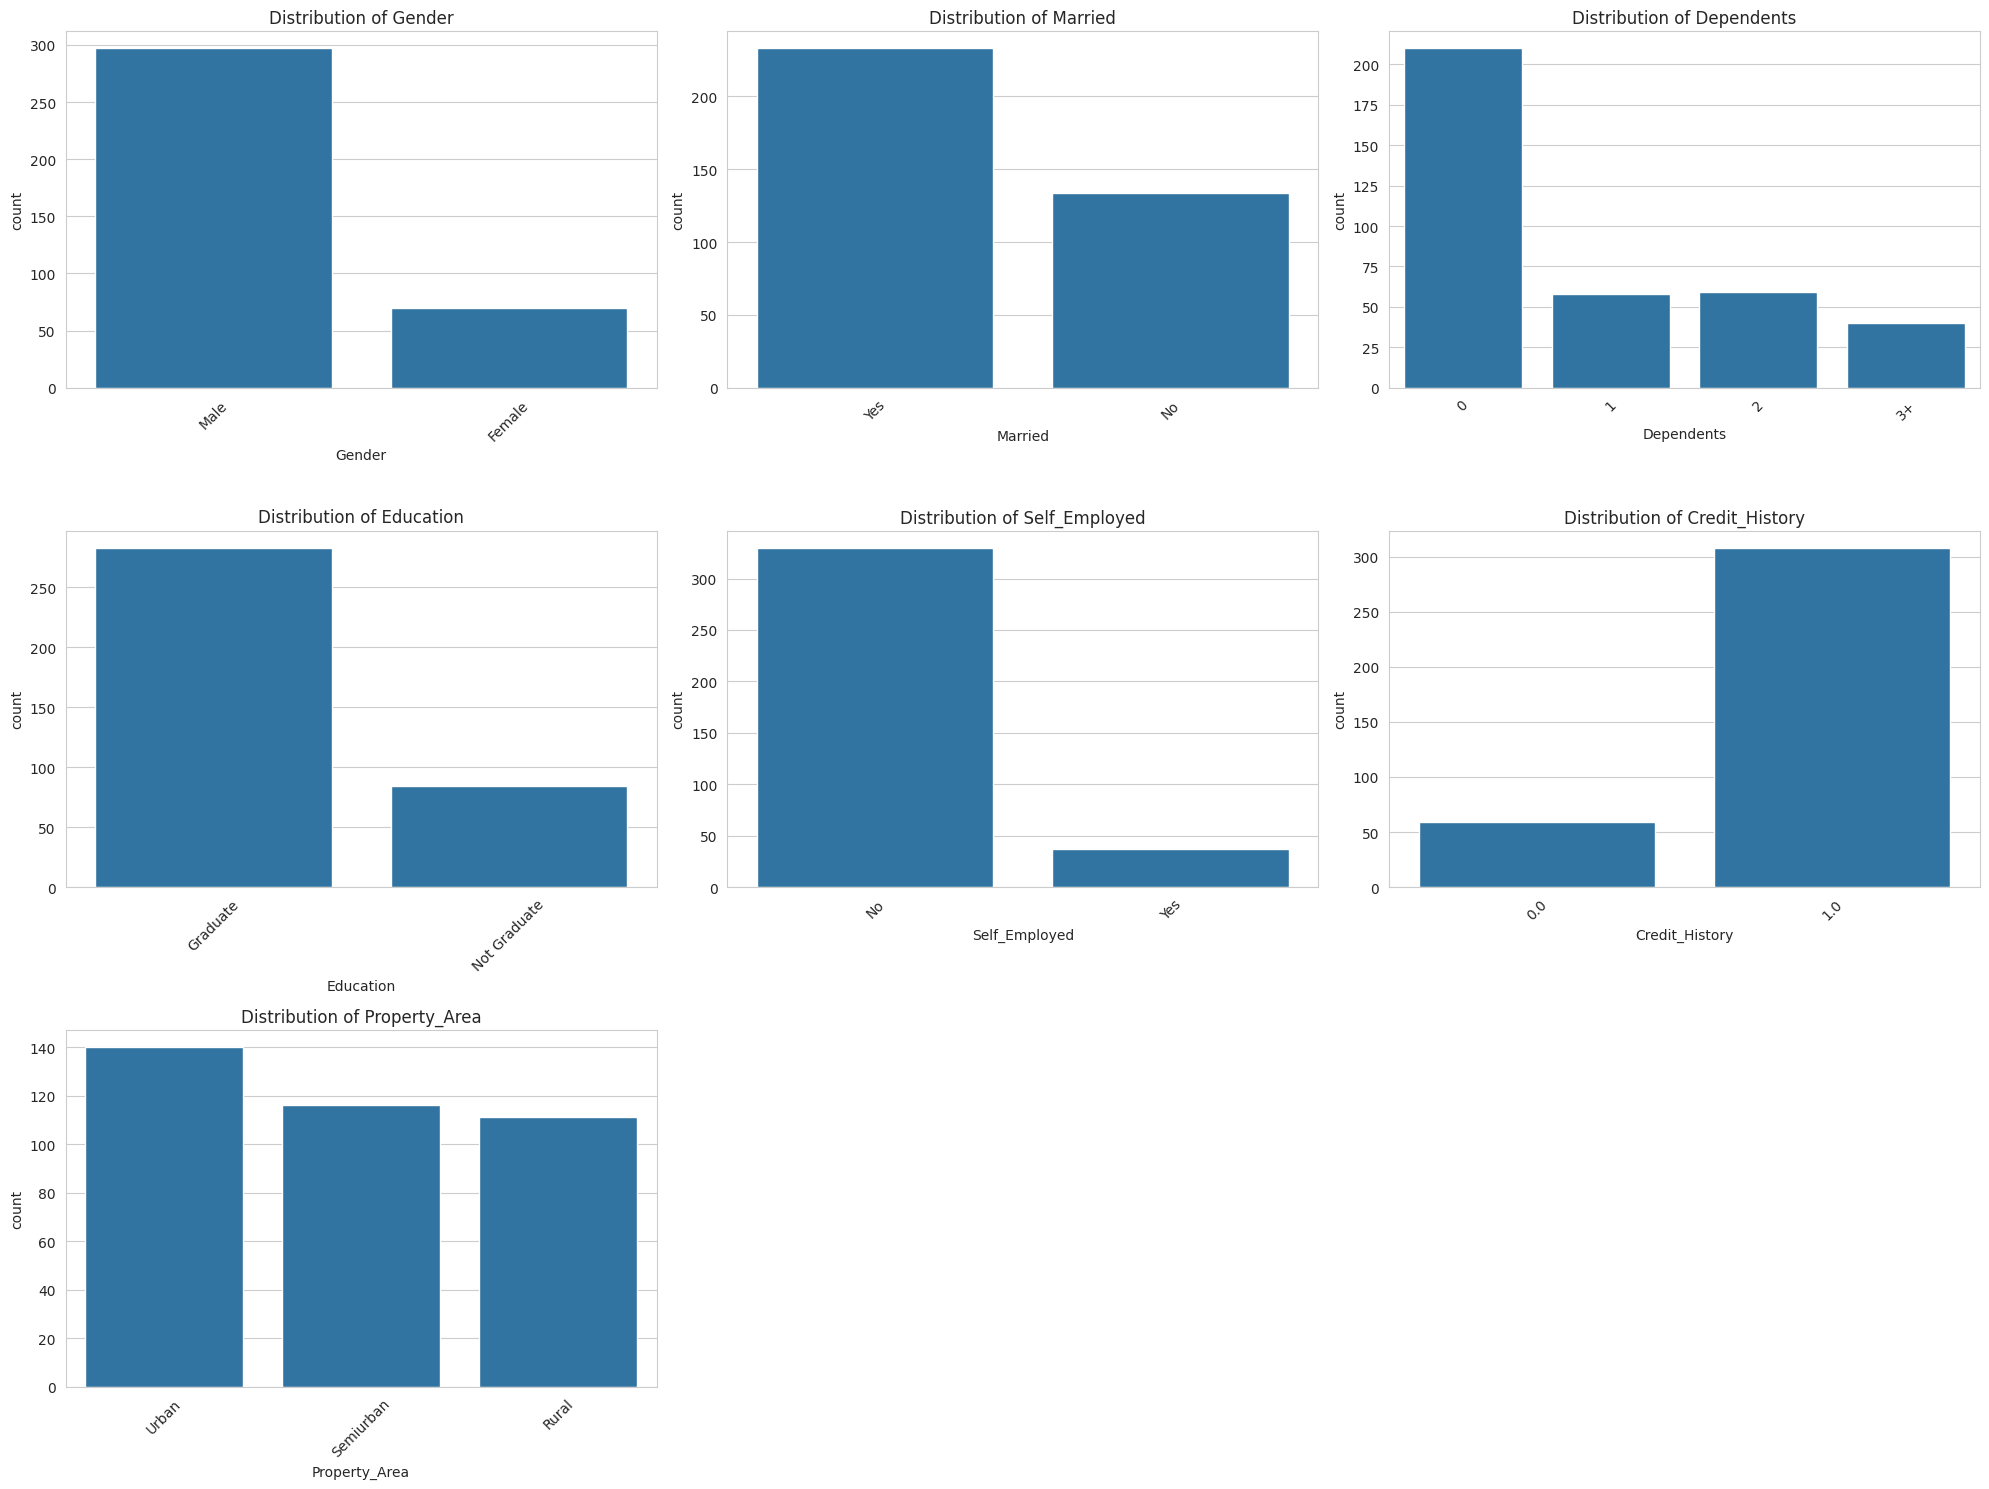

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visualize the distribution of categorical features
categorical_features = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Credit_History', 'Property_Area']

fig, axes = plt.subplots(len(categorical_features) // 3 + 1, 3, figsize=(20, 15))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    sns.countplot(data=loan_df, x=feature, ax=axes[i])
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [24]:
# Separate features (X) and target (y)
X = loan_df.drop(['Loan_ID', 'Credit_History'], axis=1) # Drop Loan_ID as it's an identifier, and Credit_History is the target
y = loan_df['Credit_History']

# Convert categorical features into numerical using one-hot encoding
X = pd.get_dummies(X, drop_first=True)

In [16]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (293, 13)
X_test shape: (74, 13)
y_train shape: (293,)
y_test shape: (74,)


In [17]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear') # 'liblinear' solver works well for small datasets and binary classification
model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


Model Accuracy: 0.74


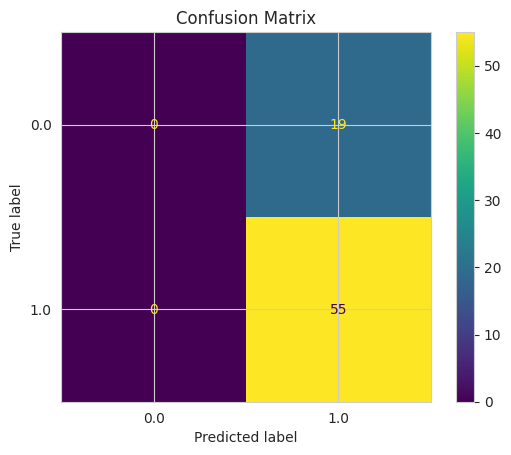

In [18]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy:.2f}")

# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
cmd_obj = ConfusionMatrixDisplay(cm, display_labels=model.classes_)
cmd_obj.plot()
cmd_obj.ax_.set_title('Confusion Matrix')
plt.show()

In [19]:
from sklearn.tree import DecisionTreeClassifier

# Initialize and train the Decision Tree Classifier
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)

print("Decision Tree Classifier trained successfully!")

Decision Tree Classifier trained successfully!


Decision Tree Model Accuracy: 0.68


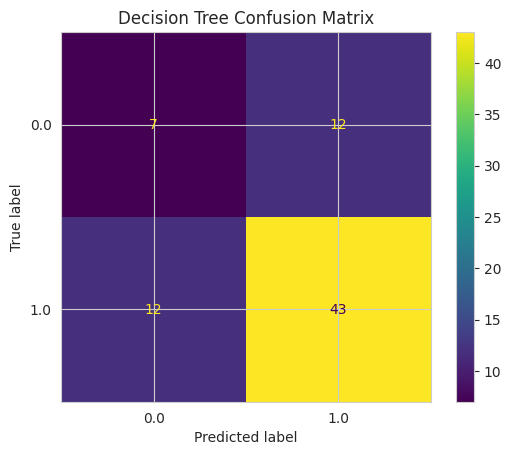

In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Make predictions on the test set using the Decision Tree model
y_pred_dtc = dtc.predict(X_test)

# Calculate accuracy for Decision Tree
accuracy_dtc = accuracy_score(y_test, y_pred_dtc)
print(f"Decision Tree Model Accuracy: {accuracy_dtc:.2f}")

# Generate confusion matrix for Decision Tree
cm_dtc = confusion_matrix(y_test, y_pred_dtc)

# Display confusion matrix for Decision Tree
cmd_obj_dtc = ConfusionMatrixDisplay(cm_dtc, display_labels=dtc.classes_)
cmd_obj_dtc.plot()
cmd_obj_dtc.ax_.set_title('Decision Tree Confusion Matrix')
plt.show()

## Summary and Model Performance

This notebook performed a binary classification task to predict 'Credit_History' using a loan dataset. After data cleaning (handling missing values) and one-hot encoding categorical features, two classification models were trained and evaluated:

*   **Logistic Regression Model:** Achieved an accuracy of **0.74**.
*   **Decision Tree Classifier:** Achieved an accuracy of **0.68**.

The Logistic Regression model demonstrated slightly better performance in terms of accuracy on this specific dataset. Further steps could include hyperparameter tuning, feature engineering, or exploring other advanced classification algorithms to improve predictive performance.